# Chapter 1. Band pass filter

One of the critical preprocessing steps in EEG signal analysis is **filtering**. EEG signals are often contaminated with noise and artifacts from various sources, including muscle activity, eye movements, and electrical interference. To isolate the brain's electrical activity of interest, filters are used to remove unwanted frequencies. A band pass filter is particularly useful in EEG signal processing, as it allows frequencies within a specific range to pass through while attenuating frequencies outside this range.

A band-pass filter combines the characteristics of both low-pass and high-pass filters. It allows frequencies within a certain range (the passband) to pass through while rejecting frequencies outside this range. The primary parameters of a band pass filter are:  
**Lower Cutoff Frequency**: The lower bound of the passband.  
**Upper Cutoff Frequency**: The upper bound of the passband.  
**Order of the Filter**: This determines the steepness of the filter's response and its attenuation outside the passband.

In the context of EEG, common frequency bands of interest include:  
**Delta** (0.5-4 Hz): Associated with deep sleep.   
**Theta** (4-8 Hz): Related to drowsiness and meditation.  
**Alpha** (8-13 Hz): Linked to relaxed, wakeful states.  
**Beta** (13-30 Hz): Associated with active thinking and focus.  
**Gamma** (30-100 Hz): Related to high-level cognitive functioning.  

## Import libraries
To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [9]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset

In [10]:
# load the Excel file as a DataFrame
eeg_data = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/signal_processing/EEG.xlsx")

display(eeg_data.head())
print (eeg_data.shape)

,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8
0,-5445.69,40705.74,2806.40,3888.94,55183.24,38844.83,-23445.19,34358.29
1,-5475.73,40672.75,2788.16,3851.65,55140.32,38835.97,-23463.97,34321.55
2,-5483.51,40669.80,2791.11,3832.34,55124.76,38838.39,-23472.01,34331.20
3,-5452.13,40710.03,2811.76,3865.06,55144.61,38853.41,-23466.92,34381.90
4,-5426.65,40740.08,2830.80,3901.54,55147.29,38858.24,-23454.31,34407.38


(10000, 8)


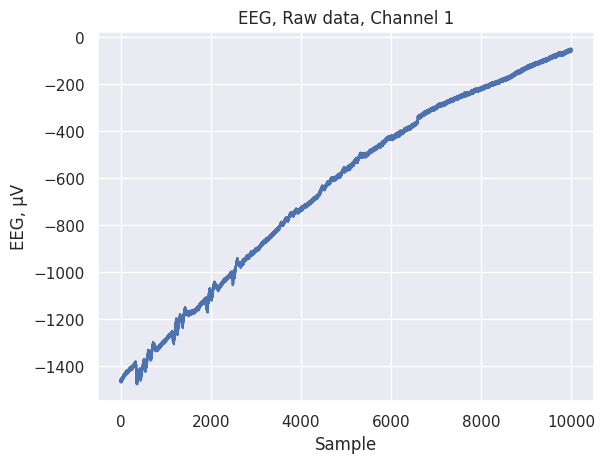

In [11]:
# select the data from the first channel
channel = 0
channel_data = eeg_data.iloc[:, channel]
# convert from Digital Value of Analog Digital converter (ADC) ADS1299 to microvolts
channel_data = round(1000000*4.5*(channel_data/16777215),2)

# plot the EEG data
plt.plot(channel_data)
plt.title("EEG, Raw data, Channel " +str(channel + 1))
plt.ylabel('EEG, µV')  # Data from ADS1299
plt.xlabel('Sample')
plt.show()

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Signal proccessing

Signal processing for EEG (Electroencephalography) data involves a range of techniques used to analyze and extract meaningful information from the electrical signals recorded from the brain. EEG signals are complex and often contaminated with noise, artifacts, and other unwanted components. Signal processing methods are essential for enhancing the signal quality, identifying patterns, and understanding brain activity.

## Band Pass Filter

Band-pass filtering is a common signal processing technique used in EEG data analysis to isolate specific frequency bands of interest while removing unwanted frequencies. Band-pass filtering allows researchers to focus on particular brainwave rhythms that are relevant to their study. For example, you might want to extract the alpha, beta, or gamma waves from the EEG data.  


**Positive**  

*   Frequency Analysis: EEG signals exhibit various frequency components (e.g., alpha, beta, delta, theta waves), each associated with different cognitive processes. A band-pass filter isolates these components, aiding frequency-specific analysis.

* Event-Related Potentials (ERPs): When studying ERPs or specific neural responses to stimuli, a band-pass filter can highlight the frequency ranges relevant to the event.

* Artifact Removal: Band-pass filters can reduce certain types of artifacts, such as low-frequency drifts or high-frequency noise, by focusing on the desired frequency range.

* Functional Connectivity: Applying consistent band-pass filtering across channels can help enhance functional connectivity analysis by removing frequencies unrelated to the neural network under investigation.

* Removing Baseline Drift: For EEG recordings, slow baseline drifts can obscure meaningful activity. Band-pass filters with cutoffs around the drift frequency can help minimize this effect.

**Negative**

*  While band-pass filters can be valuable for EEG data analysis, they can also be problematic when used inappropriately or excessively. Here are some scenarios where a band-pass filter might not be suitable for EEG processing:

* Overfiltering. Applying overly narrow band-pass filters can lead to signal distortion and the removal of genuine neural activity. Aggressive filtering might result in the loss of important frequency components.

* Misaligned Cutoff Frequencies. Setting incorrect low-pass and high-pass cutoff frequencies can result in unintended filtering of important neural oscillations or event-related potentials.

* Baseline Drift Removal. Relying solely on a band-pass filter to remove baseline drift can inadvertently remove relevant low-frequency neural signals along with the drift.

* Lack of Understanding. If you lack a clear understanding of the frequency characteristics of EEG signals and the implications of filtering, you might misuse band-pass filters and draw incorrect conclusions from your analysis.

* Data Artifacts. Band-pass filtering might not effectively remove certain types of artifacts, such as muscle artifacts or eye blinks, requiring additional preprocessing steps.

* Uneven Spectral Distribution. EEG signals often have uneven spectral distributions, and applying a uniform band-pass filter might not accurately capture the underlying neural activity.

* Inconsistent Filtering. If you apply different band-pass filters to different data segments or channels without justification, it can lead to inconsistencies in your analysis.

**How it works**   
A band-pass filter for EEG works by selectively allowing a specific range of frequencies within the EEG signal to pass through while diminishing frequencies outside that range. This is achieved through a filter design that boosts the desired frequencies and reduces amplitudes of unwanted frequencies, helping highlight neural activity in the chosen frequency band for focused analysis.

Here we use **Butterworth filters** via Scipy library. [signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) is a function provided by the [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html) module in Python. It is used to design digital Butterworth filters, which are a type of infinite impulse response (IIR) filter commonly used for signal processing tasks, including filtering EEG signals. The Butterworth filter is characterized by having a flat frequency response in its passband and a gradual roll-off in its stopband.  

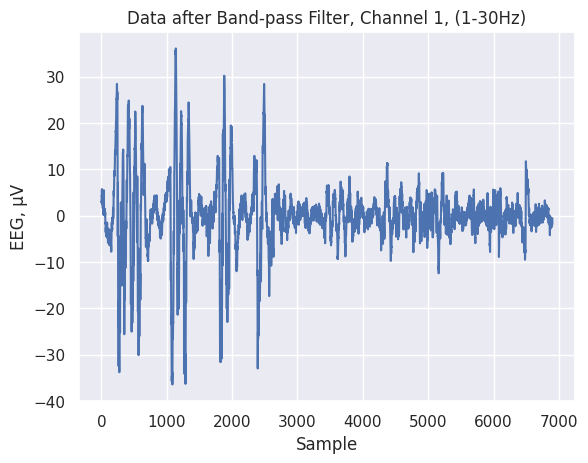

In [13]:
def butter_highpass_filter(data, cutoff, nyq, order=5):
    """Butterworth high-pass filter.
    Args:
        data (array_like): data to be filtered.
        cutoff (float): cutoff frequency.
        order (int): order of the filter.
    Returns:
        array: filtered data."""
    normal_cutoff = cutoff / nyq  # normalized cutoff frequency
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

def butter_lowpass_filter(data, cutoff, nyq, order=5):
    """Butterworth low-pass filter.
    Args:
        data (array_like): data to be filtered.
        cutoff (float): cutoff frequency.
        order (int): order of the filter.
    Returns:
        array: filtered data."""
    normal_cutoff = cutoff / nyq  # normalized cutoff frequency
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = signal.lfilter(b, a, data)
    return filtered_data

channel_data_bp_filtered = channel_data.copy()  # copy the data\
fps = 250  # sampling frequency
cutoff_high = 1  # cutoff frequency of the high-pass filter
cutoff_low = 30  # cutoff frequency of the low-pass filter
nyq = 0.5 * fps  # Nyquist frequency (half of the sampling frequency).  It represents the highest frequency that can be accurately represented in a discrete-time signal.

# apply the band-pass filter
channel_data_bp_filtered = butter_highpass_filter(
    data=channel_data_bp_filtered,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5)

channel_data_bp_filtered = butter_lowpass_filter(
    data=channel_data_bp_filtered,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4)

plt.plot(channel_data_bp_filtered[100:7000])
plt.title("Data after Band-pass Filter, Channel " +  str(channel+1) +", ("+str(cutoff_high)+"-"+str(cutoff_low) + "Hz)")
plt.ylabel('EEG, µV')
plt.xlabel('Sample')
plt.show()

**All data via band-bass filter**

Input EEG shape: (10000, 8)
Filtered EEG shape: (10000, 8)


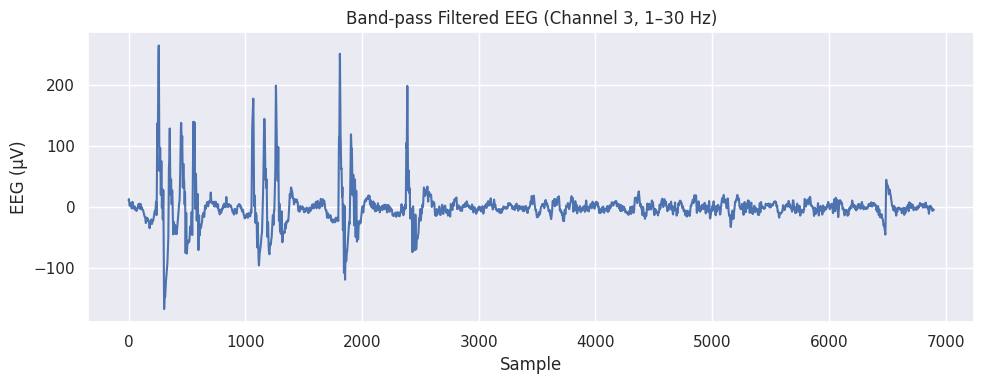

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =========================
# FILTER FUNCTIONS
# =========================

def butter_highpass_filter(data, cutoff, nyq, order=5):
    """
    Butterworth high-pass filter
    data shape: (samples, channels)
    """
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    return signal.filtfilt(b, a, data, axis=0)   # filter along time axis

def butter_lowpass_filter(data, cutoff, nyq, order=4):
    """
    Butterworth low-pass filter
    data shape: (samples, channels)
    """
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data, axis=0)   # filter along time axis

# =========================
# PARAMETERS
# =========================

fps = 250            # Sampling frequency (Hz)
cutoff_high = 1      # High-pass cutoff (Hz)
cutoff_low = 30      # Low-pass cutoff (Hz)
nyq = 0.5 * fps

# =========================
# INPUT EEG DATA
# eeg_data shape: (10000, 8)
# =========================

print("Input EEG shape:", eeg_data.shape)

# =========================
# BAND-PASS FILTER
# =========================

eeg_data_filtered = eeg_data.copy()

eeg_data_filtered = butter_highpass_filter(
    data=eeg_data_filtered,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5
)

eeg_data_filtered = butter_lowpass_filter(
    data=eeg_data_filtered,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4
)

print("Filtered EEG shape:", eeg_data_filtered.shape)

# =========================
# OPTIONAL: SAVE DATA
# =========================

np.save("eeg_bandpass_1_30Hz.npy", eeg_data_filtered)

# =========================
# PLOT ONE CHANNEL
# =========================

channel =2  # channel index (0–7)

plt.figure(figsize=(10, 4))
plt.plot(eeg_data_filtered[100:7000, channel])
plt.title(f"Band-pass Filtered EEG (Channel {channel+1}, 1–30 Hz)")
plt.ylabel("EEG (µV)")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()


average filter

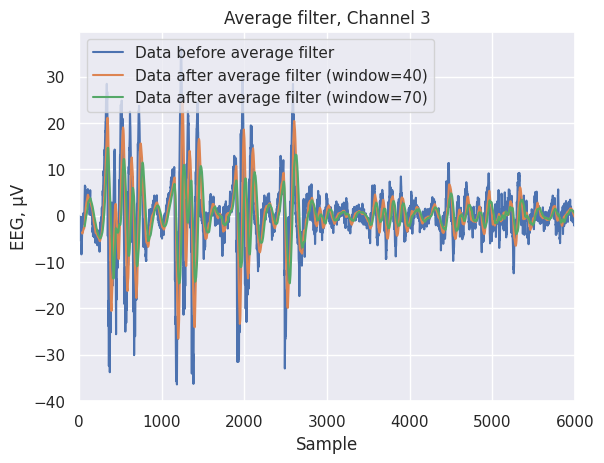

In [15]:
def average_filter(data, average_length):
    """Average filter.
    Args:
        data (array_like): data to be filtered.
        average_length (int): length of the filter window.
    Returns:
        array: filtered data."""
    data = pd.DataFrame(data)
    avereged_data = data.rolling(window=average_length).mean()
    return avereged_data

# you can control the "smoothness" of the data by changing the window size
average_length_window_1 = 40
average_length_window_2 = 70

channel_data_avg_window_1 = average_filter(data=channel_data_bp_filtered, average_length=average_length_window_1)
channel_data_avg_window_2 = average_filter(data=channel_data_bp_filtered, average_length=average_length_window_2)

plt.title("Average filter, Channel " +  str(channel+1))
plt.plot(channel_data_bp_filtered, label='Data before average filter')
plt.plot(channel_data_avg_window_1, label='Data after average filter (window='+str(average_length_window_1)+")")
plt.plot(channel_data_avg_window_2, label='Data after average filter (window='+str(average_length_window_2)+")")
plt.ylabel('EEG, µV')
plt.xlabel('Sample')
plt.legend(loc='upper left')
plt.xlim([0, 6000])  # zoom in the data
plt.show()

Gaussian Filter

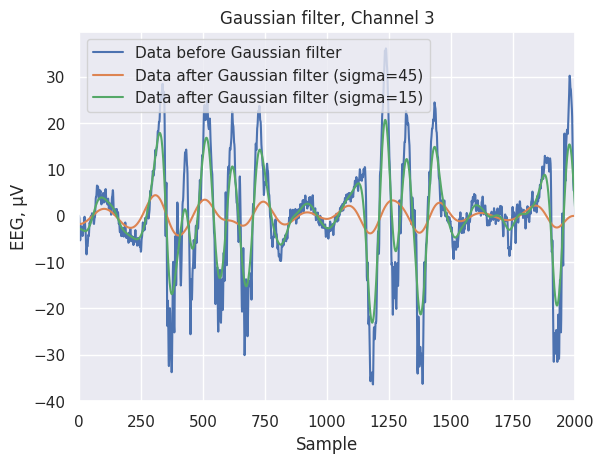

In [16]:
from scipy.ndimage import gaussian_filter1d

# you can control the "smoothness" of the data by changing
# the kernel's standard deviation value
sigma_value_1 = 45 # standard deviation of the Gaussian kernel
sigma_value_2 = 15 # standard deviation of the Gaussian kernel

channel_data_gauss_window_1 = gaussian_filter1d(channel_data_bp_filtered, sigma=sigma_value_1)
channel_data_gauss_window_2 = gaussian_filter1d(channel_data_bp_filtered, sigma=sigma_value_2)

# plot the data
plt.title("Gaussian filter, Channel " +  str(channel+1))
plt.xlabel("Sample")
plt.ylabel("EEG, µV")
plt.plot(channel_data_bp_filtered, label='Data before Gaussian filter')
plt.plot(channel_data_gauss_window_1, label='Data after Gaussian filter (sigma='+str(sigma_value_1)+")")
plt.plot(channel_data_gauss_window_2, label='Data after Gaussian filter (sigma='+str(sigma_value_2)+")")
plt.legend(loc='upper left')
plt.xlim([0, 2000])  # zoom in the data
plt.show()

Median filter

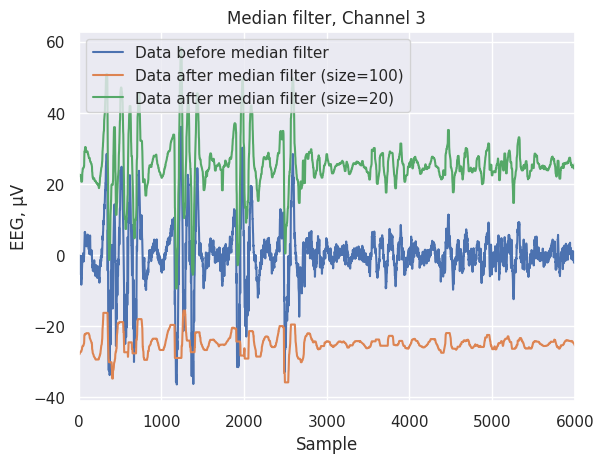

In [17]:
from scipy import ndimage

# you can control the "smoothness" of the data by changing the window size
size_window_1 = 100
size_window_2 = 20

channel_data_median_window_1 = ndimage.median_filter(channel_data_bp_filtered, size=size_window_1)  # size It defines the size of the window for the median filter operation
channel_data_median_window_2 = ndimage.median_filter(channel_data_bp_filtered, size=size_window_2)

# plot the data
plt.title("Median filter, Channel " +  str(channel+1))
plt.xlabel("Sample")
plt.ylabel('EEG, µV')

plt.plot(channel_data_bp_filtered, label='Data before median filter')
plt.plot(channel_data_median_window_1-25, label='Data after median filter (size='+str(size_window_1)+")")
plt.plot(channel_data_median_window_2+25, label='Data after median filter (size='+str(size_window_2)+")")
plt.legend(loc='upper left')
plt.xlim([0, 6000])  # zoom in the data
plt.show()

**Remove Artefacts**

Independent Component Analysis (ICA)
Independent Component Analysis (ICA) is a widely used signal processing technique for separating mixed sources in EEG data. It is particularly useful for decomposing EEG signals into their underlying independent components, which can represent different brain sources or artifacts. ICA helps to remove artifacts and identify specific brain-related activity, making it an essential tool for EEG data analysis.

ICA for removing muscle artifacts from EEG involves decomposing mixed EEG signals into statistically independent components. It identifies components that correspond to various sources, including muscle artifacts. By isolating and excluding these artifact-related components, ICA aims to enhance the quality of the EEG data.

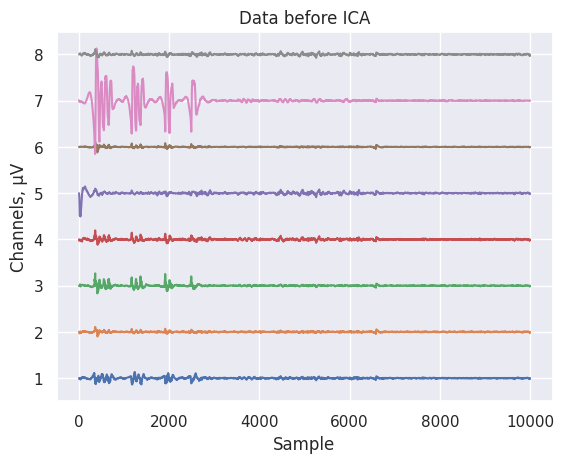

In [18]:
"""
This script visualizes multi-channel data by plotting each channel with vertical offsets to separate them,
setting y-axis ticks and labels for clarity, and adding labels and a title,
facilitating a clear view of the data before Independent Component Analysis (ICA).
"""

n_channels = eeg_data_filtered.shape[1]  # number of channels
plt.plot(eeg_data_filtered + range(1000, 1000*n_channels+1000, 1000))
plt.yticks(range(1000, 1000*n_channels+1000, 1000), range(1, n_channels+1))
plt.ylabel('Channels, µV')
plt.xlabel('Sample')
plt.title("Data before ICA")
plt.show()

The code first creates an instance of the FastICA class from the scikit-learn library,
specifying the number of components to be extracted as 8. The fit method is then called on the data_bp_filtered data, which performs the ICA decomposition and learns the unmixing matrix.
The transform method applies the learned unmixing matrix to the original data, resulting in the independent components stored in the components variable.
Next, the code plots the independent components using plt.plot,
with each component vertically offset by adding a constant value from the range(1, 1*n_channels+1, 1) sequence. This separation makes it easier to visualize the individual components.

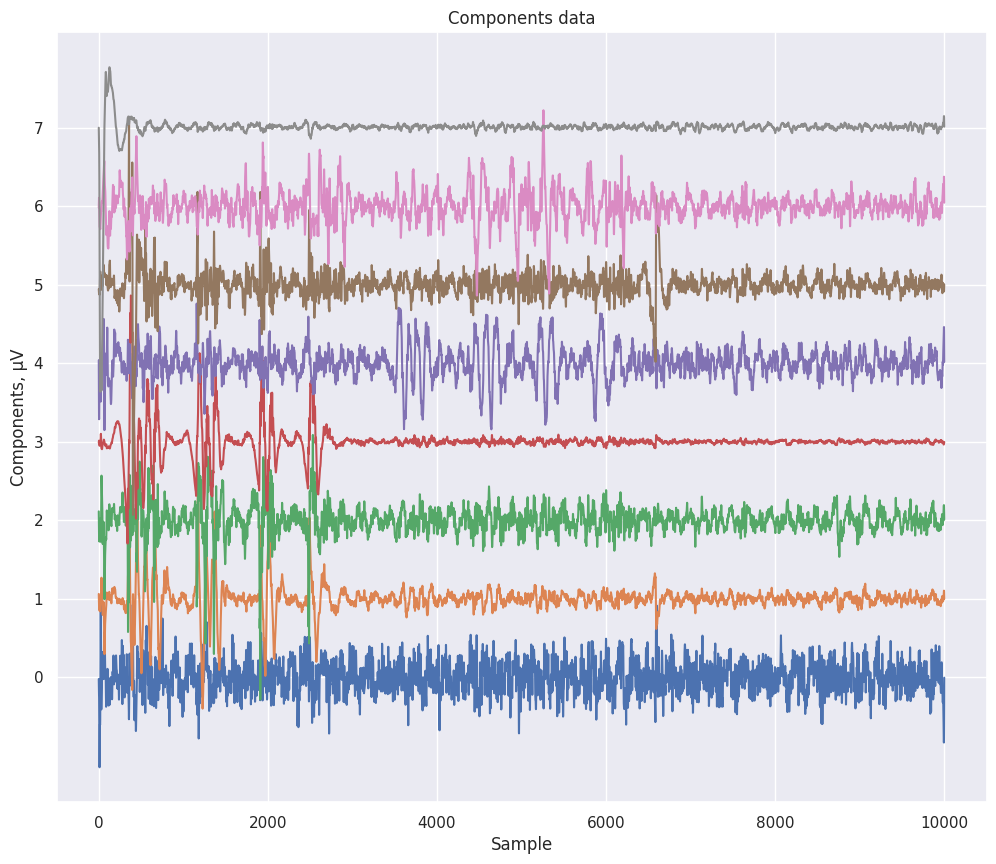

In [19]:

from sklearn.decomposition import FastICA

#pca=PCA(n_components=8)
ica=FastICA(n_components=8)

data_after_band_pass_filter_reshape = eeg_data_filtered #np.transpose(data_bp_filtered)
#data_after_band_pass_filter_reshape = data_bp_filtered #np.transpose(data_bp_filtered)

#out_pca=pca.fit_transform(data_after_band_pass_filter_reshape)
out_ica=ica.fit_transform(data_after_band_pass_filter_reshape)

#fig, ax = plt.subplots(3,1,figsize=(10,8))
ica = FastICA(n_components=8)
ica.fit(data_after_band_pass_filter_reshape)
components = ica.transform(data_after_band_pass_filter_reshape)


offset = 5  # Adjust this value to increase or decrease the spacing
plt.figure(figsize=(12, 10))  # Increase figure size for better visibility
for i in range(8):
    plt.plot(components[:, i] + offset * i)

plt.yticks(range(0, offset * 8, offset), range(0, 8))
plt.ylabel('Components, µV')
plt.xlabel('Sample')
plt.title('Components data')
plt.show()

After performing Independent Component Analysis (ICA) and visualizing the independent components, this script proceeds to remove all components except for the eye blink component (component 2) from the components matrix.
This is achieved by setting all other component values to zero using indexing operations.
The inverse_transform method of the ICA object is then called with the modified components matrix.
This method reconstructs the original data by applying the inverse of the unmixing matrix learned during the ICA decomposition.
The resulting data, stored in the restored variable, represents the original EEG data with the eye blink component removed.
Next, the code plots the restored data using plt.plot, with each channel vertically offset by adding a constant value from the range(1000, 1000*n_channels+1000, 1000) sequence.
This separation makes it easier to visualize the individual channels.

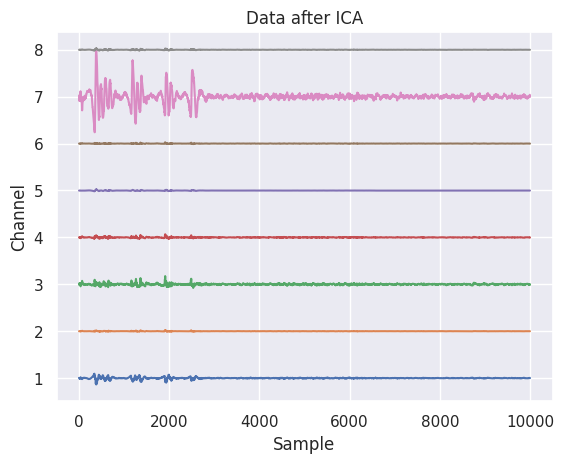

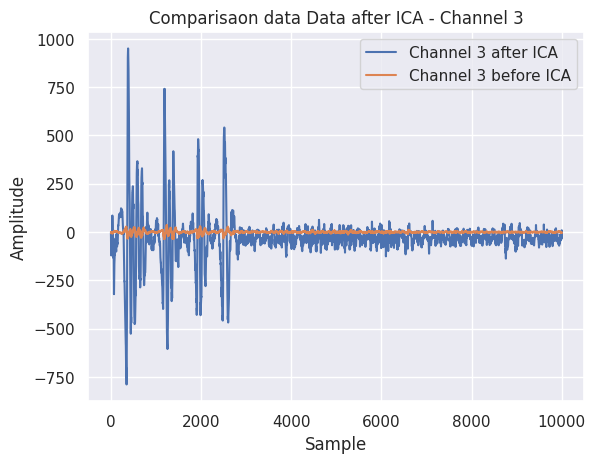

In [20]:
# remove all components except for the eye blink component (component 2)
components[:, 0] = 0
components[:, 1] = 0
#components[:, 2] = 0
#components[:, 3] = 0
components[:, 4] = 0
components[:, 5] = 0
components[:, 6] = 0
components[:, 7] = 0
# reconstruct EEG without blinks
restored = ica.inverse_transform(components)

plt.plot(restored + range(1000, 1000*n_channels+1000, 1000))
plt.yticks(range(1000, 1000*n_channels+1000, 1000), range(1, n_channels+1))
plt.ylabel('Channel')
plt.xlabel('Sample')
plt.title("Data after ICA")
plt.show()

channel_data = restored[:, 6]
plt.plot(channel_data - 30, label=f'Channel {channel + 1} after ICA')
plt.plot(channel_data_bp_filtered, label=f'Channel {channel + 1} before ICA')
plt.ylabel('Amplitude')
plt.xlabel('Sample')
plt.title("Comparisaon data Data after ICA - Channel " + str(channel+1))
plt.legend()
plt.show()

**Emperical Mode Decomposition EMD**

his Python script aims to detect and remove muscle artifacts from physiological data.
It starts by scaling the data and then applies the K-means clustering algorithm to identify artifacts.
Once an artifact is detected, it performs Empirical Mode Decomposition (EMD) to extract the artifact and replaces it with the EMD result.
Finally, it plots the original data alongside the cleaned data without artifacts.

In [21]:
!pip install EMD-signal

In [22]:
!pip install EMD-signal

ok1
Initialization complete
Iteration 0, inertia 6315.606905776793
Converged at iteration 0: center shift 0.10924518536909614 within tolerance 1000.001.
Initialization complete
Iteration 0, inertia 6898.959422828007
Converged at iteration 0: center shift 0.3054758872233134 within tolerance 1000.001.
Initialization complete
Iteration 0, inertia 7954.571348827209
Converged at iteration 0: center shift 0.41199982859255646 within tolerance 1000.001.
Initialization complete
Iteration 0, inertia 6810.785460892625
Converged at iteration 0: center shift 0.21090356282664427 within tolerance 1000.001.
Initialization complete
Iteration 0, inertia 6177.115712242845
Converged at iteration 0: center shift 0.045490740144185304 within tolerance 1000.001.
Initialization complete
Iteration 0, inertia 6175.056265217549
Converged at iteration 0: center shift 0.03793587804951879 within tolerance 1000.001.
Initialization complete
Iteration 0, inertia 8221.123935999114
Converged at iteration 0: center shift 

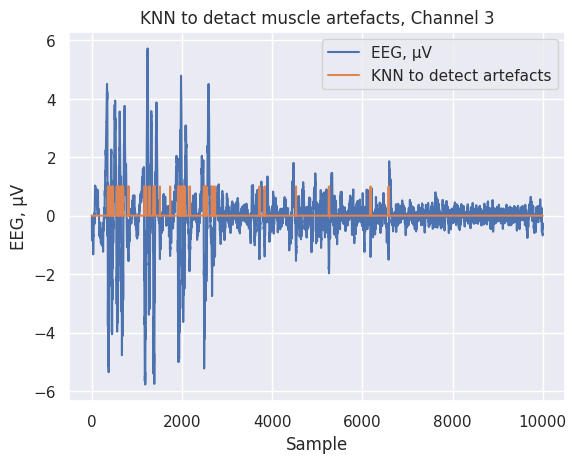

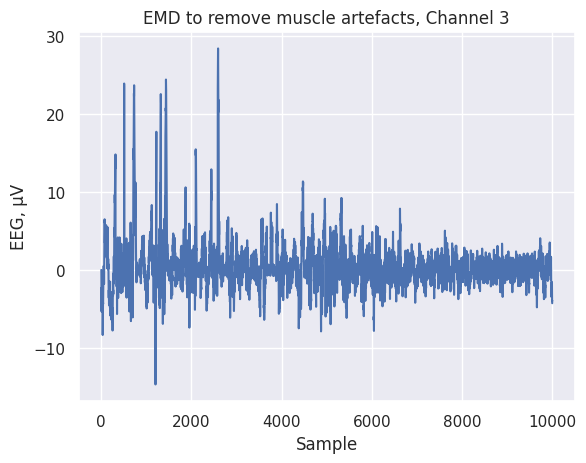

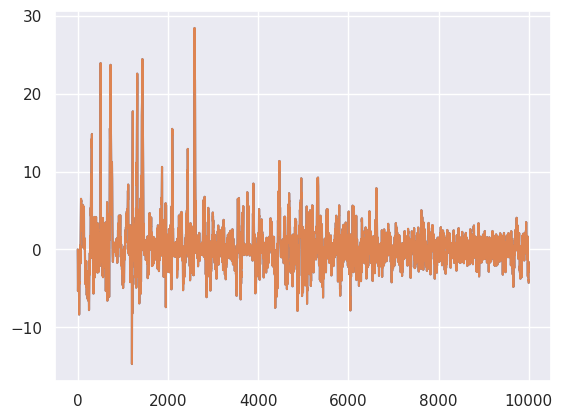

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from PyEMD import EEMD



count = 0
EMD_data = channel_data_bp_filtered



"""
This Python script aims to detect and remove muscle artifacts from physiological data.
It starts by scaling the data and then applies the K-means clustering algorithm to identify artifacts.
Once an artifact is detected, it performs Empirical Mode Decomposition (EMD) to extract the artifact and replaces it with the EMD result.
Finally, it plots the original data alongside the cleaned data without artifacts.
"""

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

EMD_data = channel_data_bp_filtered
print("ok1")



for _ in EMD_data:
    count = count+0.1
    #ime.append(count)

just_for_graph = data_for_wave = EMD_data


sc_X = StandardScaler()
data_for_wave = data_for_wave.reshape(-1,1)
scaler = sc_X.fit_transform(data_for_wave)

scaler_wave = []
for a in scaler:
    scaler_wave.append(a[0])

kmeans = KMeans(
    n_clusters=2, init='k-means++', max_iter=3, tol=1000.001,
    verbose=10, random_state=1, n_init=10,  copy_x=True,
    algorithm='elkan') #algorithm= 'auto', 'full' or 'elkan
X = scaler
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

k_means_count = 0
shift_for_filter = 20
for_do_it_one_time = 0

plt.plot(scaler)
plt.plot(y_kmeans)
plt.legend(["EEG, µV","KNN to detect artefacts"])
plt.ylabel('EEG, µV')
plt.title("KNN to detact muscle artefacts, Channel " +str(channel + 1))
plt.xlabel('Sample')
plt.show()


for a in y_kmeans:
    k_means_count = k_means_count + 1
    if k_means_count>(shift_for_filter+shift_for_filter) and k_means_count<len(EMD_data)-shift_for_filter:
        if a == 1:
            if for_do_it_one_time == 0:
                plt.cla()
                for_do_it_one_time = 1
                data_for_EMD = EMD_data[(k_means_count-shift_for_filter - shift_for_filter):(k_means_count+shift_for_filter + shift_for_filter)]

                data_for_EMD = list(data_for_EMD)
                t = np.arange(0, len(data_for_EMD), 1)

                modes = data_for_EMD
                x = modes + t

                # Define signal
                t = np.linspace(0, 1, len(data_for_EMD))
                S = data_for_EMD
                eemd = EEMD()
                emd = eemd.EMD
                emd.extrema_detection="parabol"
                eIMFs = eemd.eemd(S, t)
                nIMFs = eIMFs.shape[0]
                data_for_replace = eIMFs[1]
                #plt.plot(EMD_data)

                just_for_graph[(k_means_count-shift_for_filter - shift_for_filter):(k_means_count+shift_for_filter + shift_for_filter)] = data_for_replace
                #plt.plot(just_for_graph)
                #plt.ylabel('EEG, µV')
                #plt.title("EMD to remove muscle artefacts, Channel " +str(channel + 1))
                #plt.xlabel('Sample')

                #plt.pause(0.1)
                #plt.draw()

        else:
            for_do_it_one_time = 0
plt.plot(just_for_graph)
plt.ylabel('EEG, µV')
plt.title("EMD to remove muscle artefacts, Channel " +str(channel + 1))
plt.xlabel('Sample')

plt.pause(0.1)
plt.draw()

plt.plot(channel_data_bp_filtered)
plt.plot(just_for_graph)
plt.show()





**One Graph**

In [24]:
!pip install PyEMD

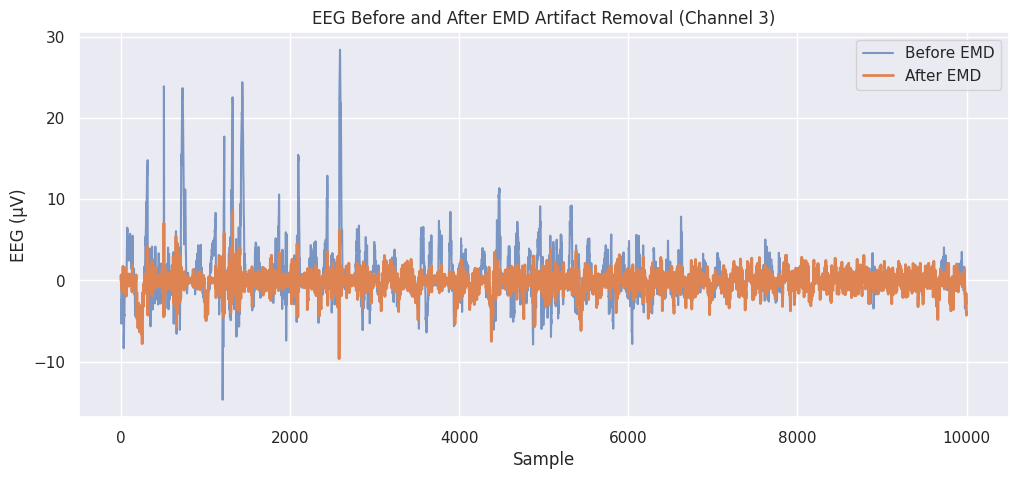

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from PyEMD import EEMD


# =======================
# Input signal
# =======================
EMD_data = np.asarray(channel_data_bp_filtered).copy()
just_for_graph = EMD_data.copy()


# =======================
# Scale data
# =======================
scaler = StandardScaler()
X = scaler.fit_transform(EMD_data.reshape(-1, 1))


# =======================
# KMeans artifact detection
# =======================
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    max_iter=3,
    tol=1000.001,
    random_state=1,
    n_init=10,
    algorithm='elkan'
)

kmeans.fit(X)
y_kmeans = kmeans.predict(X)


# =======================
# EMD parameters
# =======================
shift_for_filter = 20
k_means_count = 0
for_do_it_one_time = 0


# =======================
# Artifact removal loop (NO PLOTTING)
# =======================
for a in y_kmeans:
    k_means_count += 1

    if k_means_count > 2 * shift_for_filter and k_means_count < len(EMD_data) - shift_for_filter:

        if a == 1 and for_do_it_one_time == 0:
            for_do_it_one_time = 1

            start = k_means_count - 2 * shift_for_filter
            end   = k_means_count + 2 * shift_for_filter

            data_for_EMD = EMD_data[start:end]

            # Ensure 1-D signal for EEMD
            S = np.asarray(data_for_EMD).ravel()
            t = np.linspace(0, 1, len(S))

            eemd = EEMD()
            eemd.EMD.extrema_detection = "parabol"

            eIMFs = eemd.eemd(S, t)

            # Replace with IMF (muscle artifact usually IMF 1 or 2)
            just_for_graph[start:end] = eIMFs[1]

        elif a == 0:
            for_do_it_one_time = 0


# =======================
# FINAL PLOT (ONLY ONCE)
# =======================
plt.figure(figsize=(12, 5))
plt.plot(EMD_data, label="Before EMD", alpha=0.7)
plt.plot(just_for_graph, label="After EMD", linewidth=2)

plt.xlabel("Sample")
plt.ylabel("EEG (µV)")
plt.title(f"EEG Before and After EMD Artifact Removal (Channel {channel + 1})")
plt.legend()
#plt.tight_layout()
plt.show()


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from PyEMD import EEMD

# =======================
# Input signal
# =======================
EMD_data = np.asarray(channel_data_bp_filtered).copy()
just_for_graph = EMD_data.copy()

# =======================
# Scale data
# =======================
scaler = StandardScaler()
X = scaler.fit_transform(EMD_data.reshape(-1, 1))

# =======================
# KMeans artifact detection
# =======================
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    max_iter=3,
    tol=1000.001,
    random_state=1,
    n_init=10,
    algorithm='elkan'
)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Create binary artifact mask (1 = artifact, 0 = clean)
# Make sure artifact cluster is '1'
artifact_cluster = np.argmax([np.mean(X[y_kmeans==i]) for i in range(2)])
artifact_mask = (y_kmeans == artifact_cluster).astype(int)

# =======================
# EMD artifact removal
# =======================
shift_for_filter = 20
k_means_count = 0
for_do_it_one_time = 0

for a in y_kmeans:
    k_means_count += 1

    if k_means_count > 2 * shift_for_filter and k_means_count < len(EMD_data) - shift_for_filter:
        if a == artifact_cluster and for_do_it_one_time == 0:
            for_do_it_one_time = 1

            start = k_means_count - 2 * shift_for_filter
            end   = k_means_count + 2 * shift_for_filter

            data_for_EMD = EMD_data[start:end]

            # Ensure 1-D signal for EEMD
            S = np.asarray(data_for_EMD).ravel()
            t = np.linspace(0, 1, len(S))

            eemd = EEMD()
            eemd.EMD.extrema_detection = "parabol"

            eIMFs = eemd.eemd(S, t)

            # Replace high-frequency IMF to remove artifact
            just_for_graph[start:end] = eIMFs[1]

        elif a != artifact_cluster:
            for_do_it_one_time = 0

# =======================
# FINAL PLOT
# =======================
artifact_height = 5  # µV
artifact_plot = artifact_mask * artifact_height  # 1 → 5 µV, 0 → 0

plt.figure(figsize=(14, 5))
plt.plot(EMD_data, label="Before EMD", alpha=0.7)
plt.plot(just_for_graph, label="After EMD", linewidth=2)

# Plot artifact detection as fixed high line
plt.plot(artifact_plot, label="Detected Artifact (KMeans)", color='red', linestyle='--', alpha=0.7)

plt.xlabel("Sample")
plt.ylabel("EEG (µV)")
plt.title(f"EEG Before and After EMD Artifact Removal (Channel {channel + 1})")
plt.legend()
plt.xlim(0,1000)
plt.tight_layout()
plt.show()


Process ForkPoolWorker-540:
Process ForkPoolWorker-539:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/pool.py", line 48, in mapstar
    return list(map(*args))
           ^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/PyEMD/EEMD.py", line 238, in _trial_update
    imfs = self.emd(self._S + noise, self._T, self.max_imf)
      

KeyboardInterrupt: 

  File "/usr/lib/python3.12/multiprocessing/pool.py", line 48, in mapstar
    return list(map(*args))
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PyEMD/EMD.py", line 846, in emd
    max_env, min_env, eMax, eMin = self.extract_max_min_spline(T, imf)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PyEMD/EEMD.py", line 238, in _trial_update
    imfs = self.emd(self._S + noise, self._T, self.max_imf)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PyEMD/EMD.py", line 149, in extract_max_min_spline
    ext_res = self.find_extrema(T, S)
              ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PyEMD/EEMD.py", line 251, in emd
    return self.EMD.emd(S, T, max_imf=max_imf)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PyEMD/EMD.py", line 546, in find_extrem

**Evaluation of artifact removal**

**Notch Filter**




In [ ]:
import numpy as np
from scipy.signal import iirnotch, filtfilt
import matplotlib.pyplot as plt

# Example: your EEG channel data in microvolts
# channel_data_uv is a 1D NumPy array or pandas Series

fs = 250       # Sampling frequency in Hz
f0 = 50        # Frequency to remove (50 Hz powerline noise)
Q = 30         # Quality factor, controls the notch width

# Design notch filter
b, a = iirnotch(w0=f0, Q=Q, fs=fs)

# Apply filter using filtfilt for zero phase shift
filtered_data = filtfilt(b, a, channel_data)

# Plot original vs filtered signal
plt.figure(figsize=(12, 4))
plt.plot(channel_data, label='Original', alpha=0.7)
plt.plot(filtered_data, label='Notch Filtered', alpha=0.8)
plt.title(f'EEG Channel {channel + 1} - Notch Filter at {f0} Hz')
plt.xlabel('Sample')
plt.ylabel('EEG (µV)')
plt.legend()
plt.grid(True)
plt.show()


FFT

In [ ]:
import numpy as np
from scipy.signal import iirnotch, filtfilt
import matplotlib.pyplot as plt

# Example: your EEG channel data in microvolts
# channel_data_uv is a 1D NumPy array or pandas Series

fs = 250       # Sampling frequency in Hz
f0 = 50        # Notch frequency (powerline)
Q = 30         # Quality factor

# Design notch filter
b, a = iirnotch(w0=f0, Q=Q, fs=fs)

# Apply notch filter
filtered_data = filtfilt(b, a, channel_data)

# FFT function
def plot_fft(signal, fs, title):
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1/fs)       # Frequency bins
    fft_vals = np.abs(np.fft.rfft(signal)) # Magnitude of FFT

    plt.figure(figsize=(12, 4))
    plt.plot(freqs, fft_vals)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude (µV)')
    plt.xlim(40, 80)
    plt.ylim(0, 2000)
    plt.grid(True)
    plt.show()

# Plot FFT before and after notch filter
plot_fft(channel_data, fs, 'FFT of Original EEG Channel')
plot_fft(filtered_data, fs, 'FFT of EEG Channel After 50 Hz Notch Filter')


**SNR**

The SNR represents the ratio of the desired signal (brain activity) to the background noise (unwanted electrical activity). A higher SNR indicates that the brain signals are clearer and more distinguishable from noise, which is essential for accurate analysis. Poor SNR can lead to misinterpretation of EEG data. If noise is not properly separated from the signal, researchers may falsely conclude that certain neural responses are occurring when they are simply noise artifacts. Understanding and improving SNR is therefore vital to designing experiments that yield valid and reliable results.

The SNR before artefacts were removed is generally lower due to the presence of muscle artifacts, which can dominate the EEG signal.

In [ ]:
import numpy as np
# Calculate power of the signal
P_signal_before = np.mean(EMD_data**2)
P_signal_after = np.mean(just_for_graph**2)


plt.plot(EMD_data)
plt.show()
plt.plot(just_for_graph)
plt.show()
# Calculate power of the noise



noise = pd.read_excel("/content/drive/MyDrive/EEG_course/dataset/Noise.xlsx")

# convert from Digital Value of Analog Digital converter (ADC) ADS1299 to microvolts µV
channel_data_noise = round(1000000 * 4.5 * (noise / 16777215), 2)
P_noise = np.mean(channel_data_noise**2)

# Calculate SNR
SNR_before = 10 * np.log10(P_signal_before / P_noise)
SNR_after = 10 * np.log10(P_signal_after / P_noise)

print(f"SNR: {SNR_before:.2f} dB")
print(f"SNR: {SNR_after:.2f} dB")
